In [1]:
import os
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

from limit_states import REGISTRY as ls_REGISTRY
from utils.data import isoprobabilistic_transform

In [2]:
def compute_pareto_intervals(xx, yy, target=None, res=100_001):
    F = np.column_stack([xx, yy])
    z_star = F.max(axis=0)
    W = np.linspace(0, 1, res)
    dev = np.abs(F - z_star)
    T = np.sqrt((W[None,:] * dev[:,[0]])**2 + ((1 - W)[None,:] * dev[:,[1]])**2)
    best = np.argmin(T, axis=0)

    # 1) build intervals for all “winning” Pareto indices
    intervals = {}
    curr = best[0]
    start = 0
    for j in range(1, len(W)):
        if best[j] != curr:
            intervals.setdefault(curr, []).append((W[start], W[j-1]))
            curr = best[j]
            start = j
    intervals.setdefault(curr, []).append((W[start], W[-1]))

    # no target?  just return the full dict
    if target is None:
        return intervals

    # 2) locate the target’s index in F
    idx = None
    for i, (x,y) in enumerate(F):
        if np.isclose(x, target[0]) and np.isclose(y, target[1]):
            idx = i
            break
    if idx is None:
        return None, None

    # 3) if it already *wins* somewhere, just return its intervals
    if idx in intervals:
        return idx, intervals[idx]

    # 4) otherwise we need to find the nearest Pareto points *with* intervals
    order = np.argsort(F[:,0])  # sort by x (or pick y if you prefer)
    pos   = np.where(order == idx)[0][0]

    # scan left
    lower_idx = None
    for i in range(pos-1, -1, -1):
        cand = order[i]
        if cand in intervals:
            lower_idx = cand
            break

    # scan right
    upper_idx = None
    for i in range(pos+1, len(order)):
        cand = order[i]
        if cand in intervals:
            upper_idx = cand
            break

    # if we didn’t find both sides, we still can’t form an interval
    if lower_idx is None or upper_idx is None:
        return idx, None

    # 5) splice their boundaries:
    #    lower bound = the *furthest* right end of the lower neighbour
    low_bound  = max(end for (_, end) in intervals[lower_idx])
    #    upper bound = the *furthest* left start of the upper neighbour
    high_bound = min(start for (start, _) in intervals[upper_idx])

    return idx, [(low_bound, high_bound)]

In [ ]:
# case_it = 'four_branch_6'
# exp_it = 'mook_vs_u_eff'
# it = 129
# Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
# # assume you pick the first (or only) selected sample per iter:
# xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]
# sel_idx, sel_interval = compute_pareto_intervals(Pareto[:,0],
#                                             Pareto[:,1],
#                                             target=[xs, ys],
#                                             res=100_001)
# sel_idx, sel_interval

In [ ]:
# def load_output_data_from_name_exp(name_exp, case_study, base='results_acquisition_comparison'):
#     # Extract al_strategy from the first word before '_'
#     al_strategy = name_exp.split('_')[0]

#     config = {}
#     if al_strategy == 'moor':
#         al_strategy = 'moo'
#         config['moo_method'] = 'reliability'
#         # print(config)
#     elif al_strategy == 'mook':
#         al_strategy = 'moo'
#         config['moo_method'] = 'knee'
#     elif al_strategy == 'mooc':
#         al_strategy = 'moo'
#         config['moo_method'] = 'compromise'

#     print(f"Loading data for case study: {case_study}, AL strategy: {al_strategy}, Experiment name: {name_exp}")
#     config['case_study'] = case_study
#     config['passive_samples'] = 10
#     config['al_batch'] = 1
#     config['al_strategy'] = al_strategy
#     # # Add moo_method if needed
#     # if config['al_strategy'] == 'moo':
#     #     config['moo_method'] = 'reliability'

#     script_folder = os.getcwd()
#     base_results_dir = os.path.join(script_folder, base)
    
#     # print(config)
#     if config['al_strategy'] == 'moo':
#         dir_pattern = os.path.join(
#             base_results_dir,
#             config['case_study'],
#             f"{config['al_strategy']}_{config['moo_method']}_{config['al_batch']}_{name_exp}_*"
#         )
#     else:
#         dir_pattern = os.path.join(
#             base_results_dir,
#             config['case_study'],
#             f"{config['al_strategy']}_{config['al_batch']}_{name_exp}_*"
#         )
#     matching_dirs = glob.glob(dir_pattern)
#     output_json_path = os.path.join(matching_dirs[0], 'output.json')

#     if os.path.isfile(output_json_path):
#         with open(output_json_path, 'r') as f:
#             output_data = json.load(f)
#         return output_data
#     else:
#         raise FileNotFoundError(f"{output_json_path} not found.")

In [3]:
import os
import glob
import json

def load_output_data_from_name_exp(name_exp, case_study, base='results_revision_weights'):
    """
    Loads all output.json files for a given case study, adapting the search pattern
    based on the case_study name.

    name_exp: The experiment number (e.g., '1'), which is ignored for 'nonlinear_oscillator'.
    case_study: The name of the case study (e.g., 'four_branch_6').
    """
    
    exp_num = str(name_exp)
    experiment_data = {} 

    script_folder = os.getcwd()
    base_results_dir = os.path.join(script_folder, base)
    
    # --- Conditional Directory Pattern Creation ---
    if case_study == 'nonlinear_oscillator':
        # Search for ALL experiment numbers ('*') and ALL batches/strategies
        # Pattern: {base_results_dir}/{case_study}/*_*_*_*
        # Note: The third '*' now replaces exp_num (e.g., '1'), making it wildcarded.
        dir_pattern = os.path.join(
            base_results_dir,
            case_study,
            f"*_*_*_*"  # Matches 'strategy_batch_exp_num_timestamp' where exp_num is a wildcard
        )
    else:
        # Search only for the specified experiment number (e.g., '1')
        # Pattern: {base_results_dir}/{case_study}/*_*_{exp_num}_*
        dir_pattern = os.path.join(
            base_results_dir,
            case_study,
            f"*_*_{exp_num}_*"  # Matches 'strategy_batch_exp_num_timestamp' where exp_num is fixed
        )
    
    print(f"Searching pattern for {case_study}, Exp {exp_num}: {dir_pattern}")
    
    matching_dirs = glob.glob(dir_pattern)

    if not matching_dirs:
        print(f"No directories found for case: {case_study}.")
        return experiment_data # Return empty dict if nothing found

    # --- Data Loading Logic (Remains the same) ---
    for dir_path in matching_dirs:
        dir_name = os.path.basename(dir_path)
        parts = dir_name.split('_')
        
        # Determine the strategy key (everything before the batch size '1')
        strategy_key_parts = []
        for part in parts:
            # Assuming the batch size (which separates strategy from exp_num/timestamp) is '1'
            if part == '1': 
                break
            strategy_key_parts.append(part)
        
        # If the loop breaks early (found '1'), we use the parts collected. 
        # If not, it might mean the directory name is short, so use the first part.
        if not strategy_key_parts and parts:
             strategy_key = parts[0] # Fallback to the first element if '1' wasn't found immediately
        else:
             strategy_key = '_'.join(strategy_key_parts)
             
        # Handle the case where the strategy name itself is short (e.g., 'u', 'eff')
        if strategy_key in ['u', 'eff', 'portfolio'] and len(strategy_key_parts) == 1:
            pass # Keep the single part name

        # Handling potential ambiguity for the nonlinear_oscillator case (multiple exp_num are present)
        # We need to distinguish between experiments in the final dictionary structure.
        
        # Find the experiment number for this directory
        try:
            # Locate the experiment number in the parts list (it's the third element from the end of the strategy key)
            # The structure is assumed to be: Strategy_Batch_ExpNum_Timestamp...
            # The experiment number is the component immediately after the batch size '1'.
            
            # Since 'nonlinear_oscillator' searches for all experiments, we need to embed the exp_num
            # in the final key to avoid overwriting data from different experiments with the same strategy.
            
            # Reconstruct the experiment number based on its position after the strategy key parts
            exp_index_in_parts = len(strategy_key_parts) + 1 # Position of exp_num if batch size is one part
            
            if len(parts) > exp_index_in_parts:
                current_exp_num = parts[exp_index_in_parts]
            else:
                current_exp_num = 'unknown' # Fallback
            
        except (ValueError, IndexError):
            current_exp_num = 'unknown'

        # Create a unique key that includes the experiment number if it's not the fixed one
        final_key = strategy_key
        if case_study == 'nonlinear_oscillator':
             # For 'nonlinear_oscillator', data is grouped by strategy and experiment number
             final_key = f"{strategy_key}_{current_exp_num}"


        output_json_path = os.path.join(dir_path, 'output.json')

        if os.path.isfile(output_json_path):
            with open(output_json_path, 'r') as f:
                # Load the data and store it using the final key
                experiment_data[final_key] = json.load(f)
                print(f"   ✓ Loaded data for strategy: {final_key}")
        else:
            print(f"   ✗ Warning: No output.json found in {dir_path}")
            
    return experiment_data

In [4]:
import os
import glob
import json
import re # We'll need regex to reliably extract the experiment number

# Assuming the load_output_data_from_name_exp function from the last step is defined.

# --- Setup ---
# name_exp is now discovered automatically
case_study = ['four_branch_6', 'nonlinear_oscillator']
base_folder = 'results_revision_weights'

# Set up the base directory path
script_folder = os.getcwd()
base_results_dir = os.path.join(script_folder, base_folder)

# ── PHASE 1: LOAD ALL DATA ONCE ────────────────────────────────────
# Structure: data_by_case[case][exp][strategy] = {output_data}
data_by_case = {}

# Regex pattern to find the experiment number (assuming it's the third component 
# in the directory name, separated by underscores)
# Example dir: 'moo_reliability_1_5_2025_11_13_07_32_30' -> exp='5'
# The structure is assumed to be: {Strategy}_{Batch}_{ExpNum}_{Timestamp}
EXP_NUM_PATTERN = r'[^_]+_[^_]+_(\d+)_.*' # Matches anything_anything_(ExpNum)_anything

for case in case_study:
    print(f"\n--- Processing Case Study: {case} ---")
    data_by_case[case] = {}
    
    # 1. DISCOVER ALL EXPERIMENT NUMBERS FOR THIS CASE
    case_dir = os.path.join(base_results_dir, case)
    
    # Find all directories in the case folder
    all_case_dirs = glob.glob(os.path.join(case_dir, '*'))
    
    discovered_exp_names = set()
    
    for dir_path in all_case_dirs:
        if os.path.isdir(dir_path):
            dir_name = os.path.basename(dir_path)
            
            # Use regex to extract the experiment number
            match = re.match(EXP_NUM_PATTERN, dir_name)
            if match:
                # The first group (group 1) is the experiment number (\d+)
                exp_num = match.group(1) 
                discovered_exp_names.add(exp_num)

    # Sort the discovered experiment numbers numerically
    name_exp_discovered = sorted(list(discovered_exp_names), key=int)
    
    if not name_exp_discovered:
        print(f"No experiments found for case: {case}. Skipping.")
        continue
        
    print(f"Discovered experiment numbers for {case}: {name_exp_discovered}")

    # 2. ITERATE OVER DISCOVERED EXPERIMENTS AND LOAD DATA
    for exp in name_exp_discovered:
        # NOTE: The load_output_data_from_name_exp must be robust enough
        # to handle the two distinct behaviors you requested (fixed exp='1' vs. wildcard)
        # when called repeatedly inside this loop. The last provided version does this.
        
        all_strategies_data = load_output_data_from_name_exp(
            exp, case, base=base_folder
        )
        
        # Assign the dictionary of results to the current case/exp
        
        if case == 'nonlinear_oscillator':
            # In the last version, 'nonlinear_oscillator' loading was designed to get ALL
            # experiments in a single call, and keys were like 'strategy_expnum'.
            # To fix this conflict: When we iterate over a specific 'exp', we assume 
            # the load function only returns data relevant to that 'exp'.
            
            # --- REVERTING THE load_output_data_from_name_exp LOGIC FOR SIMPLICITY ---
            # If we iterate over 'exp' here, the load function should search *only* for that exp.
            
            # We assume a simplified load function where the search pattern is *always* # "*_*_{exp}_*" when called inside the loop.
            
            # If you are using the *last* complex version of load_output_data_from_name_exp,
            # you must *only* call it once for 'nonlinear_oscillator' outside the 'exp' loop.
            
            # --- OPTION A: STICKING TO SIMPLE ITERATION (EASIER) ---
            # If load_output_data_from_name_exp searches for *only* the passed 'exp':
            
            # This handles all strategies for the current 'exp'.
            data_by_case[case][exp] = all_strategies_data
            
        else:
            # This handles all strategies for the current 'exp'.
            data_by_case[case][exp] = all_strategies_data


# The loop is now independent of a predefined name_exp list.
# You will need to ensure your latest version of `load_output_data_from_name_exp`
# is available and handles the experiment number parameter correctly based on this structure.


--- Processing Case Study: four_branch_6 ---
Discovered experiment numbers for four_branch_6: ['1']
Searching pattern for four_branch_6, Exp 1: /Users/jonathan/Documents/MOAL/acquisition/MOO-AL/results_revision_weights/four_branch_6/*_*_1_*
   ✓ Loaded data for strategy: moo_eps_lw
   ✓ Loaded data for strategy: u
   ✓ Loaded data for strategy: eff
   ✓ Loaded data for strategy: portfolio
   ✓ Loaded data for strategy: moo_compromise
   ✓ Loaded data for strategy: moo_knee
   ✓ Loaded data for strategy: moo_reliability

--- Processing Case Study: nonlinear_oscillator ---
Discovered experiment numbers for nonlinear_oscillator: ['1']
Searching pattern for nonlinear_oscillator, Exp 1: /Users/jonathan/Documents/MOAL/acquisition/MOO-AL/results_revision_weights/nonlinear_oscillator/*_*_*_*
   ✓ Loaded data for strategy: moo_eps_lw_1
   ✓ Loaded data for strategy: moo_knee_1
   ✓ Loaded data for strategy: moo_reliability_1
   ✓ Loaded data for strategy: moo_compromise_2
   ✓ Loaded data for 

In [5]:
strategies_data = data_by_case[case][exp]
out = strategies_data['portfolio_1']
idx = 300
Pareto = np.array(out['Pareto_metrics'][idx][0])
xs, ys = out['Pareto_metrics'][idx][1]
grid_resolution = 100_001

_, sel_interval = compute_pareto_intervals(
Pareto[:, 0], # First objective
    Pareto[:, 1], # Second objective
    target=[-xs, ys],
    res=grid_resolution
            )
sel_interval

[(0.9998600000000001, 0.9999800000000001)]

In [ ]:
xs, ys

In [ ]:
import numpy as np
# Assuming compute_pareto_intervals is available in the current scope
# Assuming case_study and data_by_case are populated from the previous step

# ── 1) PRE‐COMPUTE ALL INTERVAL MEANS ───────────────────────────────
# The structure is: interval_mean[case][exp][strategy] = np.array(sel_intervals)
interval_mean = {}
grid_resolution = 100_001

for case in case_study:
    interval_mean[case] = {}
    
    # Iterate over all discovered experiment numbers (exp) loaded for this case
    # We use data_by_case[case].keys() to get all the 'exp' indices found.
    # Note: data_by_case[case] is a dictionary where keys are experiment numbers ('1', '2', etc.)
    for exp in data_by_case[case].keys():
        
        # data_by_case[case][exp] is a dictionary of {strategy: output_data}
        strategies_data = data_by_case[case][exp]
        
        interval_mean[case][exp] = {} # Initialize dictionary for strategies
        
        # Iterate over all strategies loaded for this case and experiment
        for strategy, out in strategies_data.items():
            print(f"Processing: Case {case}, Exp {exp}, Strategy {strategy}")

            # Check if 'Pareto_metrics' exists and has data
            if 'Pareto_metrics' not in out or not out['Pareto_metrics']:
                print(f"   Skipping: No 'Pareto_metrics' found for {strategy}.")
                continue
                
            N_it = len(out['Pareto_metrics'])

            # Collect one sel_interval per iteration
            sel_intervals = []
            
            for idx in range(N_it):
                # out['Pareto_metrics'][idx] is a tuple: (Pareto, (xs, ys))
                
                # Ensure the structure is correct before indexing
                if len(out['Pareto_metrics'][idx]) != 2 or len(out['Pareto_metrics'][idx][1]) != 2:
                     print(f"   Warning: Pareto_metrics structure for iter {idx} is invalid. Skipping.")
                     sel_intervals.append(None)
                     continue
                     
                Pareto = np.array(out['Pareto_metrics'][idx][0])
                xs, ys = out['Pareto_metrics'][idx][1]
                
                # Ensure Pareto array has two columns (f1 and f2)
                if Pareto.ndim != 2 or Pareto.shape[1] < 2:
                    print(f"   Warning: Pareto data for iter {idx} is invalid. Skipping.")
                    sel_intervals.append(None)
                    continue

                # compute_pareto_intervals returns (all_intervals, sel_interval)
                # Note: We negate Pareto[:,0] because compute_pareto_intervals likely
                # assumes minimization for the first objective, and the MOO problem 
                # might involve maximizing the first metric (Pf reduction or utility).
                try:
                    _, sel_interval = compute_pareto_intervals(
                        Pareto[:, 0], # First objective (e.g., negative utility)
                        Pareto[:, 1], # Second objective (e.g., reliability index error)
                        target=[-xs, ys], # Target point (selected sample metrics)
                        res=grid_resolution
                    )
                    # Note: sel_interval is a list of weight intervals, e.g., [(low, high)]
                    sel_intervals.append(sel_interval)
                except Exception as e:
                    print(f"   Error in compute_pareto_intervals for iter {idx}: {e}")
                    sel_intervals.append(None) # Append None if computation fails

            # Filter out None values from computation or when selected sample not on the Pareto front
            # Also, flatten the list of intervals (which is typically one element: [(low, high)])
            # into just the (low, high) tuple.
            filtered_intervals = [interval[0] for interval in sel_intervals if interval is not None and len(interval) == 1]
            
            # Store the resulting array of intervals: array([[low1, high1], [low2, high2], ...])
            if filtered_intervals:
                interval_mean[case][exp][strategy] = np.array(filtered_intervals, dtype=float)
            else:
                 print(f"   Warning: No valid intervals computed for {strategy}. Storing empty array.")
                 interval_mean[case][exp][strategy] = np.array([], dtype=float).reshape(0, 2)

# Example of how to access the results:
# mean_for_eff = interval_mean['four_branch_6']['1']['eff']

In [6]:
import pickle

# with open(f'intervals_res_{grid_resolution}.pkl', 'wb') as file_id:
#     pickle.dump(interval_mean, file_id)

with open('intervals_res_100001.pkl', 'rb') as file_id:
    interval_mean = pickle.load(file_id)

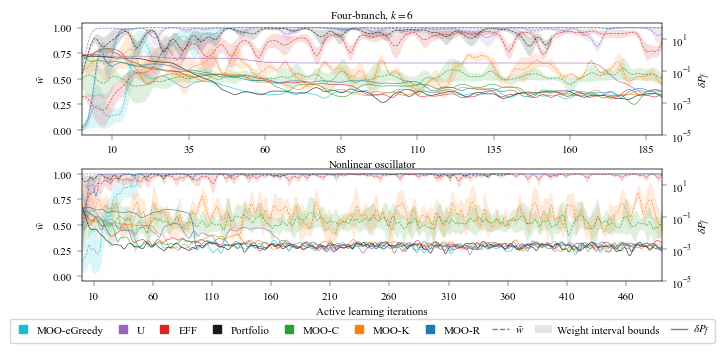

In [11]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm 
# Assuming the following variables are defined from your previous steps:
# data_by_case, interval_mean, ls_REGISTRY, compute_pareto_intervals, etc.

# --- Case-specific constants and plotting setup ---

# Strategy colors 
strategy_colors = {
    'moo_reliability': "#1f77b4", # Blue
    'moo_knee':        '#ff7f0e', # Orange
    'moo_compromise':  '#2ca02c', # Green
    'moo_eps_lw':      "#17becf", # Yellow/Gold (NEW COLOR)
    'eff':             '#d62728', # Red
    'u':               '#9467bd', # Purple
    'portfolio':       "#1a1717", # Near Black
}

# FILTERED STRATEGY MAP 
strategy_map_filtered = {
    'moo_reliability': r'MOO-R',
    'moo_knee':        r'MOO-K',
    'moo_compromise':  r'MOO-C',
    'moo_eps_lw':      r'MOO-eGreedy', # (NEW LABEL)
    'eff':             r'EFF',
    'u':               r'U',
    'portfolio':       r'Portfolio',
}

case_map = {
    'four_branch_6':       r'Four-branch, $k=6$',
    'nonlinear_oscillator': r'Nonlinear oscillator',
}

max_iterations = {
    'four_branch_6': 190, # 200 max samples - 10 passive
    'nonlinear_oscillator': 490, # 500 max samples - 10 passive
}

# Assume 'name_exp_to_plot' is defined, using the first discovered experiment
if 'name_exp_to_plot' not in locals() and 'data_by_case' in locals():
    # Attempt to infer the experiment number if not already defined
    name_exp_to_plot = sorted(list(data_by_case['four_branch_6'].keys()), key=int)
exp_num_to_use = name_exp_to_plot[0] 

# Get the list of strategies to actually plot (keys from the filtered map)
strategies_to_plot = set(strategy_map_filtered.keys())

# -------------- Configuration ----------------
font_size = 8
linewidth = 0.3
sigma = 1.5
cm = 1/2.54 
plt.rcParams.update({
    'font.size': font_size, 'legend.fontsize': font_size, 'legend.title_fontsize': font_size,
    'axes.titlesize': font_size, 'axes.labelsize': font_size,
    'xtick.labelsize': font_size, 'ytick.labelsize': font_size,
    'font.family': 'Times New Roman', 'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth, 'xtick.major.width': linewidth, 'ytick.major.width': linewidth,
    'lines.linewidth': 0.5, 'grid.linewidth': 0.5,
})

# -------------- Plotting ----------------

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19*cm, 9*cm), sharex=False)
case_study_list = ['four_branch_6', 'nonlinear_oscillator']

# Y-axis padding constant
Y_PAD = 0.05 

for idx, case in enumerate(case_study_list):
    ax = axes[idx]
    ax2 = ax.twinx() 

    exp_num = exp_num_to_use 
        
    if exp_num not in data_by_case[case]:
        print(f"No data found for {case} with experiment number {exp_num}. Skipping.")
        continue
            
    strategies_data = data_by_case[case][exp_num]

    for full_strategy_key, out in strategies_data.items():
            
        # --- Determine the base strategy for color lookup ---
        base_strategy = full_strategy_key.split('_')[0]
        
        # Complex MOO logic check - UPDATED TO INCLUDE 'moo_eps_lw'
        if base_strategy == 'moo':
            if full_strategy_key.startswith('moo_reliability'):
                base_strategy = 'moo_reliability'
            elif full_strategy_key.startswith('moo_knee'):
                base_strategy = 'moo_knee'
            elif full_strategy_key.startswith('moo_compromise'):
                base_strategy = 'moo_compromise'
            elif full_strategy_key.startswith('moo_eps_lw'): # NEW CHECK
                base_strategy = 'moo_eps_lw'
        # Alias check (in case data keys still use old format 'moor_1_...')
        elif full_strategy_key.startswith('moor'): # Check full key for reliable alias mapping
            base_strategy = 'moo_reliability'
        elif full_strategy_key.startswith('mook'):
            base_strategy = 'moo_knee'
        elif full_strategy_key.startswith('mooc'):
            base_strategy = 'moo_compromise'
        
        # --- Check if the strategy should be plotted ---
        if base_strategy not in strategies_to_plot:
            continue
            
        label_base = strategy_map_filtered.get(base_strategy, base_strategy)
        line_color = strategy_colors.get(base_strategy, 'black')
        
        # --- Plot Weight Intervals (AX - LEFT AXIS) ---
        if full_strategy_key in interval_mean[case][exp_num] and interval_mean[case][exp_num][full_strategy_key].size > 0:
            ivals = interval_mean[case][exp_num][full_strategy_key].squeeze() 
            if ivals.ndim == 1:
                ivals = ivals.reshape(1, 2)
                
            mean_vals = ivals.mean(axis=1)
            lower_bounds = ivals[:, 0]
            upper_bounds = ivals[:, 1]
            n_iter_weight = len(mean_vals)
            iterations_weight = np.arange(n_iter_weight)

            mean_gf = gaussian_filter1d(mean_vals, sigma, mode='nearest')
            lower_gf = gaussian_filter1d(lower_bounds, sigma, mode='nearest')
            upper_gf = gaussian_filter1d(upper_bounds, sigma, mode='nearest')
            
            label = label_base
            
            ax.plot(iterations_weight, mean_gf,
                 linestyle='dashed', linewidth=0.5, alpha=0.8,
                 color=line_color,
                 label=label) 
            
            ax.fill_between(iterations_weight,
                     lower_gf, upper_gf,
                     color=line_color, alpha=0.15, linewidth=0.0)

        # --- Plot Delta Pf (AX2 - RIGHT AXIS) ---
        if 'Pf_model' in out:
            try:
                 Pf_ref = ls_REGISTRY[case]().target_pf 
            except NameError:
                 Pf_ref = 1e-4
                 
            pf_model = out['Pf_model']
            delta_pf = np.abs(np.array(pf_model) - Pf_ref) / Pf_ref
            n_iter_delta = len(delta_pf)
            iterations_delta = np.arange(n_iter_delta)
            
            delta_gf = gaussian_filter1d(delta_pf, sigma, mode='nearest')
            
            ax2.plot(iterations_delta, delta_gf,
                alpha=0.8,
                linestyle='-', linewidth=0.5,
                color=line_color) 

    # --- Axis labels and title ---
    ax.set_ylabel(r'$\bar w$') 
    
    # Y-AXIS GAP 
    ax.set_yticks(np.arange(0, 1.25, 0.25))
    ax.set_ylim(0 - Y_PAD, 1 + Y_PAD) 
    
    ax2.set_ylabel(r'$\delta P_f$') 
    ax2.set_yscale('log')
    ax2.set_ylim(1e-5, 1e2)

    if idx == len(case_study_list) - 1:
        ax.set_xlabel('Active learning iterations')
    
    ax.set_title(case_map.get(case, case), pad=0.1)

    # --- Grid and Limits (X-AXIS Ticks Updated) ---
    max_it = max_iterations[case]
    ax.grid(True, linestyle='--', alpha=0.1)
    
    # X-limit starts at 0 to show the initial point
    ax.set_xlim(0, max_it) 
    
    # X-AXIS TICKS (Corrected to match previous request: start from 10, go slightly beyond max_it for neatness)
    if max_it == 190:
        ax.set_xticks(np.arange(10, 201, 25))
    elif max_it == 490:
        ax.set_xticks(np.arange(10, 501, 50))


# -------------- Custom Legends ----------------
strategy_handles = []
strategy_labels = []
plotted_strategies = set()

for line in axes[0].get_lines():
    label = line.get_label()
    if label and label not in plotted_strategies:
        strategy_handles.append(Line2D([0], [0], marker='s', color=line.get_color(), linestyle=''))
        strategy_labels.append(label)
        plotted_strategies.add(label)

# Generic style handles for line types
mean_handle    = Line2D([0], [0], linestyle='--', color='grey', linewidth=1,
                      label=r'$\bar w$')
bounds_patch   = Patch(facecolor='grey', alpha=0.2, linewidth=0.0,
                     label='Weight interval bounds')
delta_pf_handle = Line2D([0], [0], color='grey', linestyle='-',
                      linewidth=1, label=r'$\delta P_f$')

# Order: Strategy Handles + Weight Mean + Weight Bounds + Delta Pf
all_handles_ordered = strategy_handles + [mean_handle, bounds_patch, delta_pf_handle]
all_labels_ordered  = strategy_labels  + [r'$\bar w$', 'Weight interval bounds', r'$\delta P_f$'] 

fig.legend(all_handles_ordered, all_labels_ordered,
           loc='lower center', ncol=len(strategy_handles) + 3, frameon=True, 
           columnspacing=1.0, handletextpad=0.5, handlelength=1.5,
           bbox_to_anchor=(0.5, -0.04, 0.0, 0.0))

plt.subplots_adjust(bottom=0.15, hspace=0.3)
plt.show()

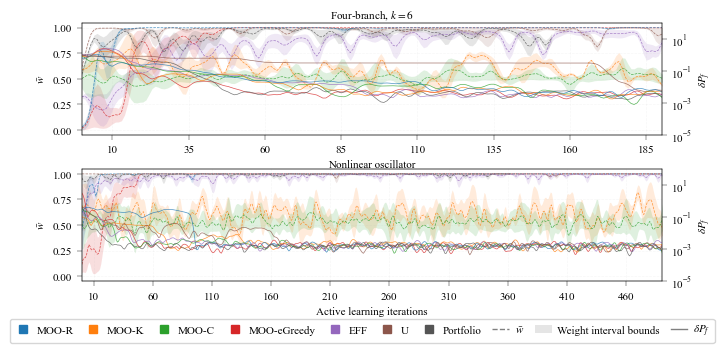

In [14]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm 
# Assuming the following variables are defined from your previous steps:
# data_by_case, interval_mean, ls_REGISTRY, compute_pareto_intervals, etc.

# --- Case-specific constants and plotting setup ---

# 1. DEFAULT MATPLOTLIB COLOR CYCLE (tab10)
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# STRATEGY ORDER for Color and Legend (MOO first):
ordered_strategies = [
    'moo_reliability', 'moo_knee', 'moo_compromise', 'moo_eps_lw',
    'eff', 'u', 'portfolio'
]

strategy_colors = {
    ordered_strategies[0]: default_colors[0], # Blue
    ordered_strategies[1]: default_colors[1], # Orange
    ordered_strategies[2]: default_colors[2], # Green
    ordered_strategies[3]: default_colors[3], # Reddish-Orange
    ordered_strategies[4]: default_colors[4], # Purple
    ordered_strategies[5]: default_colors[5], # Brown/Red
    ordered_strategies[6]: default_colors[6], # Pink/Maroon (or manually set to a dark gray)
}
if len(ordered_strategies) > 6:
    strategy_colors['portfolio'] = '#555555' 


# FILTERED STRATEGY MAP 
strategy_map_filtered = {
    'moo_reliability': r'MOO-R',
    'moo_knee':        r'MOO-K',
    'moo_compromise':  r'MOO-C',
    'moo_eps_lw':      r'MOO-eGreedy', 
    'eff':             r'EFF',
    'u':               r'U',
    'portfolio':       r'Portfolio',
}

case_map = {
    'four_branch_6':       r'Four-branch, $k=6$',
    'nonlinear_oscillator': r'Nonlinear oscillator',
}

max_iterations = {
    'four_branch_6': 190, # 200 max samples - 10 passive
    'nonlinear_oscillator': 490, # 500 max samples - 10 passive
}

# Assumed variables for plotting iteration (Exp 1 assumed)
if 'name_exp_to_plot' not in locals() and 'data_by_case' in locals():
    name_exp_to_plot = sorted(list(data_by_case['four_branch_6'].keys()), key=int)
exp_num_to_use = name_exp_to_plot[0] 

strategies_to_plot = set(strategy_map_filtered.keys())

# -------------- Configuration ----------------
font_size = 8
linewidth = 0.3
sigma = 1.5
cm = 1/2.54 
plt.rcParams.update({
    'font.size': font_size, 'legend.fontsize': font_size, 'legend.title_fontsize': font_size,
    'axes.titlesize': font_size, 'axes.labelsize': font_size,
    'xtick.labelsize': font_size, 'ytick.labelsize': font_size,
    'font.family': 'Times New Roman', 'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth, 'xtick.major.width': linewidth, 'ytick.major.width': linewidth,
    'lines.linewidth': 0.5, 'grid.linewidth': 0.5,
})

# -------------- Plotting ----------------

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19*cm, 9*cm), sharex=False)
case_study_list = ['four_branch_6', 'nonlinear_oscillator']

# Tracker for strategies that actually have data plotted on the first subplot (axes[0])
plotted_strategies_tracker = set()

Y_PAD = 0.05 

for idx, case in enumerate(case_study_list):
    ax = axes[idx]
    ax2 = ax.twinx() 

    exp_num = exp_num_to_use 
        
    if exp_num not in data_by_case[case]:
        print(f"No data found for {case} with experiment number {exp_num}. Skipping.")
        continue
            
    strategies_data = data_by_case[case][exp_num]

    for full_strategy_key, out in strategies_data.items():
            
        # --- Determine the base strategy for color lookup ---
        base_strategy = full_strategy_key.split('_')[0]
        
        if base_strategy == 'moo':
            if full_strategy_key.startswith('moo_reliability'): base_strategy = 'moo_reliability'
            elif full_strategy_key.startswith('moo_knee'): base_strategy = 'moo_knee'
            elif full_strategy_key.startswith('moo_compromise'): base_strategy = 'moo_compromise'
            elif full_strategy_key.startswith('moo_eps_lw'): base_strategy = 'moo_eps_lw'
        elif full_strategy_key.startswith('moor'): base_strategy = 'moo_reliability'
        elif full_strategy_key.startswith('mook'): base_strategy = 'moo_knee'
        elif full_strategy_key.startswith('mooc'): base_strategy = 'moo_compromise'
        
        if base_strategy not in strategies_to_plot:
            continue
            
        label_base = strategy_map_filtered.get(base_strategy, base_strategy)
        line_color = strategy_colors.get(base_strategy, '#000000') 
        
        # --- Plot Weight Intervals (AX - LEFT AXIS) ---
        is_plotted = False
        if full_strategy_key in interval_mean[case][exp_num] and interval_mean[case][exp_num][full_strategy_key].size > 0:
            ivals = interval_mean[case][exp_num][full_strategy_key].squeeze() 
            if ivals.ndim == 1: ivals = ivals.reshape(1, 2)
                
            mean_vals = ivals.mean(axis=1)
            lower_bounds = ivals[:, 0]
            upper_bounds = ivals[:, 1]
            n_iter_weight = len(mean_vals)
            iterations_weight = np.arange(n_iter_weight)

            mean_gf = gaussian_filter1d(mean_vals, sigma, mode='nearest')
            lower_gf = gaussian_filter1d(lower_bounds, sigma, mode='nearest')
            upper_gf = gaussian_filter1d(upper_bounds, sigma, mode='nearest')
            
            # Plot without label
            ax.plot(iterations_weight, mean_gf,
                 linestyle='dashed', linewidth=0.5, alpha=0.8,
                 color=line_color) 
            
            ax.fill_between(iterations_weight,
                     lower_gf, upper_gf,
                     color=line_color, alpha=0.15, linewidth=0.0)
            is_plotted = True


        # --- Plot Delta Pf (AX2 - RIGHT AXIS) ---
        if 'Pf_model' in out:
            try: Pf_ref = ls_REGISTRY[case]().target_pf 
            except NameError: Pf_ref = 1e-4
                 
            pf_model = out['Pf_model']
            delta_pf = np.abs(np.array(pf_model) - Pf_ref) / Pf_ref
            n_iter_delta = len(delta_pf)
            iterations_delta = np.arange(n_iter_delta)
            
            delta_gf = gaussian_filter1d(delta_pf, sigma, mode='nearest')
            
            ax2.plot(iterations_delta, delta_gf,
                alpha=0.8,
                linestyle='-', linewidth=0.5,
                color=line_color) 
            is_plotted = True # Mark as plotted if Pf data is present

        # Track which strategies were plotted in the *first* subplot (for legend generation)
        if idx == 0 and is_plotted:
            plotted_strategies_tracker.add(base_strategy)


    # --- Axis labels and title ---
    ax.set_ylabel(r'$\bar w$') 
    ax.set_yticks(np.arange(0, 1.25, 0.25))
    ax.set_ylim(0 - Y_PAD, 1 + Y_PAD) 
    
    ax2.set_ylabel(r'$\delta P_f$') 
    ax2.set_yscale('log')
    ax2.set_ylim(1e-5, 1e2)

    if idx == len(case_study_list) - 1:
        ax.set_xlabel('Active learning iterations')
    
    ax.set_title(case_map.get(case, case), pad=0.1)

    # --- Grid and Limits (X-AXIS Ticks Updated) ---
    max_it = max_iterations[case]
    ax.grid(True, linestyle='--', alpha=0.1)
    ax.set_xlim(0, max_it) 
    
    if max_it == 190:
        ax.set_xticks(np.arange(10, 201, 25))
    elif max_it == 490:
        ax.set_xticks(np.arange(10, 501, 50))

# --- Custom Legends and MOO Ordering ---
strategy_handles = []
strategy_labels = []

# Filter and sort the handles/labels based on the desired MOO-first order
for strat_key in ordered_strategies:
    # Check if the strategy was actually plotted in the first subplot
    if strat_key in plotted_strategies_tracker:
        label = strategy_map_filtered.get(strat_key)
        
        # We rely on the fixed color map/order
        strategy_handles.append(Line2D([0], [0], marker='s', color=strategy_colors[strat_key], linestyle=''))
        strategy_labels.append(label)

# Generic style handles for line types
mean_handle    = Line2D([0], [0], linestyle='--', color='grey', linewidth=1,
                      label=r'$\bar w$')
bounds_patch   = Patch(facecolor='grey', alpha=0.2, linewidth=0.0,
                     label='Weight interval bounds')
delta_pf_handle = Line2D([0], [0], color='grey', linestyle='-',
                      linewidth=1, label=r'$\delta P_f$')

# Order: Strategy Handles (MOO first) + Weight Mean + Weight Bounds + Delta Pf
all_handles_ordered = strategy_handles + [mean_handle, bounds_patch, delta_pf_handle]
all_labels_ordered  = strategy_labels  + [r'$\bar w$', 'Weight interval bounds', r'$\delta P_f$'] 

fig.legend(all_handles_ordered, all_labels_ordered,
           loc='lower center', ncol=len(strategy_handles) + 3, frameon=True, 
           columnspacing=1.0, handletextpad=0.5, handlelength=1.5,
           bbox_to_anchor=(0.5, -0.04, 0.0, 0.0))

plt.subplots_adjust(bottom=0.15, hspace=0.3)
plt.show()

In [15]:
fig.savefig(f'invertals_evolution_comparison.pdf', bbox_inches='tight')

In [ ]:
# -------------- Configuration ----------------
font_size = 8
linewidth = 0.3
sigma = 1.5
cm = 1/2.54  # centimeters in inches
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth,
    'xtick.major.width': linewidth,
    'ytick.major.width': linewidth,
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'xtick.minor.size': 2.0,    # shorter minor ticks
    'ytick.minor.size': 2.0,
})

# -------------- Utilities ----------------
def calculate_reliability_index(Pf):
    Pf = np.array(Pf, dtype=np.float64)
    B = -norm.ppf(Pf)
    B[np.isinf(B)] = 10.0
    return B

strategy_map = {
    'moor': r'MOO-R',
    'mooc': r'MOO-C',
    'mook': r'MOO-K',
    'eff':  r'EFF',
    'u':    r'U',
}
case_map = {
    'four_branch_6':       r'Four-branch, $k=6$',
    'nonlinear_oscillator': r'Nonlinear oscillator',
}

# -------------- Plotting ----------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19*cm, 9*cm), sharex=True)
for idx, case in enumerate(case_study):
    ax = axes[idx]
    ax2 = ax.twinx()

    # reference for delta
    Pf_ref = ls_REGISTRY[case]().target_pf
    b_ref = calculate_reliability_index([Pf_ref])[0]

    for exp in name_exp:
        strategy_key = exp.split('_')[0]
        label_base = strategy_map.get(strategy_key, strategy_key)

        # compute delta beta
        pf_model = data_by_case[case][exp]['Pf_model']
        b_model = calculate_reliability_index(pf_model)
        delta = np.abs(b_model - b_ref) / b_ref
        iterations = np.arange(len(delta))

        # compute interval mean and bounds
        ivals = interval_mean[case][exp].squeeze()  # shape (n_iter, 2)
        mean_vals = ivals.mean(axis=1)
        lower_bounds = ivals[:, 0]
        upper_bounds = ivals[:, 1]

        # plot delta with gaussian filter
        delta_gf = gaussian_filter1d(delta, sigma, mode='nearest')
        ax.plot(iterations, delta_gf,
            alpha=0.8,
            linestyle='-', linewidth=0.8,
            label=f'{label_base}')
        
        # plot interval mean and bounds
        mean_gf = gaussian_filter1d(mean_vals, sigma, mode='nearest')
        lower_gf = gaussian_filter1d(lower_bounds, sigma, mode='nearest')
        upper_gf = gaussian_filter1d(upper_bounds, sigma, mode='nearest')
        
        ax2.plot(iterations[:len(mean_vals)], mean_gf,
             linestyle=(0, (5, 5)), linewidth=0.8, alpha=0.8)
        ax2.fill_between(iterations[:len(mean_vals)],
                 lower_gf, upper_gf,
                 alpha=0.15)

    # Axis labels and title
    ax.set_ylabel(r'$\delta\beta$')
    if idx == len(case_study) - 1:
        ax.set_xlabel(rf'Active learning iterations: $t$')

    ax2.set_ylabel(r'$\bar w$')
    ax2.set_yticks(np.arange(0, 1.25, 0.25))
    ax2.set_ylim(-0.05, 1.05)

    ax.set_yscale('log')
    ax.set_title(case_map.get(case, case), pad=0.1)

    # grid
    ax.grid(True, linestyle='--', alpha=0.1)
    ax.set_xticks(np.arange(0, 191, 25))
    ax.set_xlim(0, 190)
    # set y-limits
    ax.set_yticks([1e-4, 1e-3, 1e-2, 1e-1])
    ax.set_ylim(1e-4, 1e0)

    # Move ax2 (secondary y-axis) to the left
    ax2.yaxis.set_label_position("left")
    ax2.yaxis.tick_left()

    # Move ax (primary y-axis) to the right
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

# -------------- Custom Legends ----------------
# Strategy color handles (from first subplot's lines with marker 'o')
strategy_handles = []
strategy_labels = []
for line in axes[0].get_lines():
    # if line.get_marker() == '':
    strategy_handles.append(Line2D([0], [0], marker= 's', color=line.get_color(), linestyle=''))
    strategy_labels.append(line.get_label())

# Generic style handles
delta_handle = Line2D([0], [0], color='grey', linestyle='-',
                      linewidth=1, label=r'$\delta\beta$')
mean_handle  = Line2D([0], [0], linestyle='--', color='grey', linewidth=1,
                      label=r'$\bar w$')
bounds_patch = Patch(facecolor='grey', alpha=0.2,
                     label='Weight interval bounds')

# Place combined legend at bottom
all_handles = strategy_handles + [delta_handle, mean_handle, bounds_patch]
all_labels = strategy_labels + [r'$\delta\beta$', r'$\bar w$', 'Weight interval bounds']
fig.legend(all_handles, all_labels,
           loc='lower center', ncol=len(strategy_handles) + 3, frameon=True, 
           columnspacing=1.0, handletextpad=0.5, handlelength=1.5,bbox_to_anchor=(0.5, -0.05, 0.0, 0.0))

# plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.subplots_adjust(bottom=0.15)
plt.show()

In [ ]:
fig.savefig(f'invertals_evolution_comparison.pdf', bbox_inches='tight')

In [ ]:
case_it = 'four_branch_6'
exp_it = 'mook_vs_u_eff'
it = 129
Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
# assume you pick the first (or only) selected sample per iter:
xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]
sel_idx, sel_interval = compute_pareto_intervals(Pareto[:,0],
                                            Pareto[:,1],
                                            target=[xs, ys],
                                            res=100_001)

In [ ]:
case_it = 'four_branch_6'
exp_it = 'mook_vs_u_eff'
for it in range(len(data_by_case[case_it][exp_it]['Pareto_metrics'])):
    if it > 125:
            Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
            # assume you pick the first (or only) selected sample per iter:
            xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]

            # compute_pareto_intervals returns (all_intervals, sel_interval)
            _, sel_interval = compute_pareto_intervals(Pareto[:,0],
                                                       Pareto[:,1],
                                                       target=[xs, ys],
                                                       res=100_001)
        # size = len(data_by_case['four_branch_6']['mook_vs_u_eff']['Pareto_metrics'][it][0])
            print(f'it: {it}, {xs, ys} {sel_interval}')


In [ ]:
name_exp_moo    = ['moor_vs_u_eff', 'mooc_vs_u_eff', 'mook_vs_u_eff']
case_study  = ['four_branch_6', 'nonlinear_oscillator']

Pareto_size = {}
for case in case_study:
    Pareto_size[case] = {}
    for exp in name_exp_moo:
        Pareto_size[case][exp] = []
        iterations = len(data_by_case[case][exp]['Pareto_metrics'])
        for idx in range(iterations):
            Pareto = data_by_case[case][exp]['Pareto_metrics'][idx][0]
            Pareto_size[case][exp].append(len(Pareto))

In [ ]:
# --- styling ---
font_size = 8; linewidth = 0.3; cm = 1/2.54
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth,
    'xtick.major.width': linewidth,
    'ytick.major.width': linewidth,
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
})

fig, ax = plt.subplots(figsize=(10*cm, 7*cm))

# --- lines (no per-line labels; we build legends manually) ---
for case in case_study:
    for exp in name_exp_moo:
        strat = exp.split('_')[0]               # 'moor'|'mooc'|'mook'
        sizes = np.array(Pareto_size[case][exp])
        iters = np.arange(1, len(sizes)+1)
        sm = gaussian_filter1d(sizes, sigma=2, mode='nearest')
        ax.plot(
            iters, sm,
            color=strategy_color[strat],
            linestyle=case_linestyle[case],
            linewidth=1.0,
            alpha=0.9,
        )

ax.set_xlabel(r'Active learning iterations: $t$')
ax.set_ylabel(r'Pareto set size: $K$')
ax.set_yscale('log')
ax.set_xticks(np.arange(0, 191, 25))
ax.set_xlim(0, 190)
ax.set_ylim(5, 1e4)
ax.grid(True, linestyle='--', alpha=0.1)

# --- legend A: strategies (bottom, colored squares) ---
strat_handles = [
    Line2D([0],[0], marker='s', linestyle='', color=strategy_color[k], markersize=6)
    for k in strategy_map_moo
]
strat_labels = [strategy_map_moo[k] for k in strategy_map_moo]

# --- legend B: cases (upper-left, black lines with linestyles) ---
case_handles = [
    Line2D([0],[0], color='black', linestyle=case_linestyle[c], linewidth=1.0)
    for c in case_study
]
case_labels = [case_map[c] for c in case_study]
leg_case = ax.legend(
    case_handles, case_labels,
    loc='upper left',
    frameon=True,
)
leg_case.get_frame().set_linewidth(0.5)

fig.legend(
    strat_handles, strat_labels,
    loc='lower center',
    ncol=len(strat_handles),
    frameon=True,
    bbox_to_anchor=(0.5, 0.07)
)

# --- ensure bottom space for legend ---
fig.subplots_adjust(bottom=0.3)
plt.show()

In [ ]:
N_pool = 1_000_000  # 1e6

# --- styling ---
font_size = 8; linewidth = 0.3; cm = 1/2.54
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth,
    'xtick.major.width': linewidth,
    'ytick.major.width': linewidth,
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
})

fig, ax = plt.subplots(figsize=(10*cm, 7*cm))

# --- lines ---
for case in case_study:
    for exp in name_exp_moo:
        strat = exp.split('_')[0]
        sizes = np.array(Pareto_size[case][exp]) / N_pool * 100  # percentage
        iters = np.arange(1, len(sizes)+1)
        sm = gaussian_filter1d(sizes, sigma=2, mode='nearest')
        ax.plot(
            iters, sm,
            color=strategy_color[strat],
            linestyle=case_linestyle[case],
            linewidth=1.0,
            alpha=0.9,
        )

ax.set_xlabel(r'Active learning iterations: $t$')
ax.set_ylabel(r'$K/N_{\mathrm{pool}}$')

# log-scale percentage axis
ax.set_yscale('log')
ax.set_ylim(1e-2, 1)  # from 0.01% up to 100%

# nice log ticks: 100%, 10%, 1%, 0.1%, 0.01%
ax.set_yticks([1e-3, 1e-2, 1e-1, 1])
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}%"))

ax.set_xticks(np.arange(0, 191, 25))
ax.set_xlim(0, 190)

# --- legend A: strategies (bottom, colored squares) ---
strat_handles = [
    Line2D([0],[0], marker='s', linestyle='', color=strategy_color[k], markersize=6)
    for k in strategy_map_moo
]
strat_labels = [strategy_map_moo[k] for k in strategy_map_moo]

# --- legend B: cases (upper-left, black lines with linestyles) ---
case_handles = [
    Line2D([0],[0], color='black', linestyle=case_linestyle[c], linewidth=1.0)
    for c in case_study
]
case_labels = [case_map[c] for c in case_study]
leg_case = ax.legend(
    case_handles, case_labels,
    loc='upper left',
    frameon=True,
)

fig.legend(
    strat_handles, strat_labels,
    loc='lower center',
    ncol=len(strat_handles),
    frameon=True,
    bbox_to_anchor=(0.5, -0.15)
)

ax.grid(True, which="both", linestyle='--', alpha=0.1)



In [ ]:
fig.savefig(
    'Pareto_size_evolution_moo.pdf',
    bbox_inches='tight'
)